In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split



In [45]:
# Read csv data 
path = "/Users/bimphomthong/Library/Mobile Documents/com~apple~CloudDocs/Learning-icloud/data-science-ml/ml_ai_learning_by_doing/PIRvision_FoG_presence_detection/pirvision_fog_presence_detection/"
train_data1 = pd.read_csv(path + 'pirvision_office_dataset1.csv')
train_data2 = pd.read_csv(path + 'pirvision_office_dataset2.csv')

# concatenate the two dataframes row-wise
train_data = pd.concat([train_data1, train_data2], ignore_index=True)

# Check the data
display(train_data)

# Move the label column to the last column
label_col = train_data['Label'].copy()
train_data = train_data.drop(columns=['Label'])
train_data['target'] = label_col

# Check the data
display(train_data)

# summary of the data
display(train_data.describe())




,Date,Time,Label,Temperature_F,PIR_1,PIR_2,PIR_3,PIR_4,PIR_5,PIR_6,...,PIR_46,PIR_47,PIR_48,PIR_49,PIR_50,PIR_51,PIR_52,PIR_53,PIR_54,PIR_55
0,2024-08-08,19:19:56,0,86,10269,10721,11156,11170,10931,10671,...,11178,11197,11161,11096,10957,10839,10735,10590,10411,10329
1,2024-08-08,19:20:12,1,86,10364,10907,11299,11238,10867,10535,...,11122,11145,11136,11108,11041,10824,10645,10493,10398,10357
2,2024-08-08,19:20:28,0,86,10329,10793,11197,11242,11052,10658,...,11168,11204,11162,11109,11007,10867,10700,10533,10427,10265
3,2024-08-08,19:20:44,0,86,10169,10425,10822,11133,11136,10834,...,11116,11273,11186,10984,10910,10807,10714,10651,10562,10463
4,2024-08-08,19:21:00,0,86,10320,10667,11104,11234,11129,10814,...,11006,11257,11370,11173,10924,10816,10754,10588,10428,10407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15297,2024-10-08,04:34:17,0,88,10648,11474,11989,11891,11424,10861,...,11873,11947,11856,11725,11562,11335,11129,10820,10599,10438
15298,2024-10-08,04:34:33,0,88,10412,11083,11796,12000,11612,10999,...,11785,11948,11912,11811,11652,11430,11103,10829,10614,10465
15299,2024-10-08,04:34:49,0,88,10412,10780,11555,11860,11541,11101,...,11690,11815,11813,11746,11573,11395,11222,11070,10909,10696
15300,2024-10-08,04:35:05,0,88,10697,11502,12022,11957,11436,10794,...,11895,11989,11898,11672,11506,11189,10866,10700,10509,10426


,Date,Time,Temperature_F,PIR_1,PIR_2,PIR_3,PIR_4,PIR_5,PIR_6,PIR_7,...,PIR_47,PIR_48,PIR_49,PIR_50,PIR_51,PIR_52,PIR_53,PIR_54,PIR_55,target
0,2024-08-08,19:19:56,86,10269,10721,11156,11170,10931,10671,10395,...,11197,11161,11096,10957,10839,10735,10590,10411,10329,0
1,2024-08-08,19:20:12,86,10364,10907,11299,11238,10867,10535,10173,...,11145,11136,11108,11041,10824,10645,10493,10398,10357,1
2,2024-08-08,19:20:28,86,10329,10793,11197,11242,11052,10658,10288,...,11204,11162,11109,11007,10867,10700,10533,10427,10265,0
3,2024-08-08,19:20:44,86,10169,10425,10822,11133,11136,10834,10520,...,11273,11186,10984,10910,10807,10714,10651,10562,10463,0
4,2024-08-08,19:21:00,86,10320,10667,11104,11234,11129,10814,10453,...,11257,11370,11173,10924,10816,10754,10588,10428,10407,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15297,2024-10-08,04:34:17,88,10648,11474,11989,11891,11424,10861,10133,...,11947,11856,11725,11562,11335,11129,10820,10599,10438,0
15298,2024-10-08,04:34:33,88,10412,11083,11796,12000,11612,10999,10339,...,11948,11912,11811,11652,11430,11103,10829,10614,10465,0
15299,2024-10-08,04:34:49,88,10412,10780,11555,11860,11541,11101,10621,...,11815,11813,11746,11573,11395,11222,11070,10909,10696,0
15300,2024-10-08,04:35:05,88,10697,11502,12022,11957,11436,10794,10228,...,11989,11898,11672,11506,11189,10866,10700,10509,10426,0


,Temperature_F,PIR_1,PIR_2,PIR_3,PIR_4,PIR_5,PIR_6,PIR_7,PIR_8,PIR_9,...,PIR_47,PIR_48,PIR_49,PIR_50,PIR_51,PIR_52,PIR_53,PIR_54,PIR_55,target
count,15302.000000,1.530200e+04,15302.000000,15302.000000,15302.000000,15302.000000,15302.000000,15302.000000,15302.000000,15302.000000,...,15302.000000,15302.000000,15302.000000,15302.000000,15302.000000,15302.000000,15302.000000,15302.000000,15302.000000,15302.000000
mean,80.383871,2.501256e+05,11013.891648,11517.838452,11578.490786,11269.104169,10795.036989,10312.208600,9907.840413,9610.574958,...,11559.512874,11541.448438,11439.599529,11283.987061,11103.084564,10919.279441,10743.028624,10585.803294,10449.395373,0.332767
std,22.860670,4.292858e+06,591.779937,656.662381,663.090247,605.916326,537.230304,501.390737,499.616070,522.012929,...,627.975644,619.176515,598.543624,571.501348,546.292700,518.324545,487.192649,464.733099,450.216603,0.818451
min,0.000000,2.613000e+03,2615.000000,2614.000000,2611.000000,2612.000000,2613.000000,2616.000000,2614.000000,2615.000000,...,2606.000000,2606.000000,2605.000000,2605.000000,2609.000000,2605.000000,2604.000000,2603.000000,2602.000000,0.000000
25%,86.000000,1.033300e+04,10787.250000,11272.250000,11338.000000,11051.000000,10629.000000,10182.000000,9764.000000,9410.000000,...,11313.000000,11301.000000,11211.000000,11083.000000,10935.250000,10794.000000,10650.000000,10513.000000,10388.000000,0.000000
50%,86.000000,1.043100e+04,11002.000000,11557.000000,11629.000000,11301.000000,10790.000000,10311.000000,9910.000000,9597.000000,...,11583.000000,11566.000000,11471.000000,11319.000000,11137.000000,10948.000000,10760.000000,10597.000000,10454.000000,0.000000
75%,88.000000,1.056075e+04,11267.000000,11885.000000,11957.000000,11550.000000,10982.000000,10443.000000,10035.000000,9762.000000,...,11961.000000,11928.000000,11781.000000,11571.000000,11334.000000,11097.000000,10876.000000,10683.000000,10524.000000,0.000000
max,89.000000,1.116026e+08,16383.000000,16383.000000,16383.000000,16383.000000,16383.000000,16383.000000,16383.000000,16383.000000,...,16383.000000,16383.000000,16383.000000,16383.000000,16383.000000,16383.000000,16383.000000,16383.000000,16383.000000,3.000000


In [46]:
train_data['target'].value_counts()

target
0    12494
1     1666
3     1142
Name: count, dtype: int64

In [47]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(train_data.iloc[:, :-1], train_data['target'], test_size=0.2, random_state=42, shuffle=True, stratify=train_data['target'])

In [48]:
y_train.value_counts()

target
0    9995
1    1333
3     913
Name: count, dtype: int64

In [52]:
#X_train = X_train.drop(columns=['Date', 'Time'])
X_train

,Temperature_F,PIR_1,PIR_2,PIR_3,PIR_4,PIR_5,PIR_6,PIR_7,PIR_8,PIR_9,...,PIR_46,PIR_47,PIR_48,PIR_49,PIR_50,PIR_51,PIR_52,PIR_53,PIR_54,PIR_55
13331,86,10306,10827,11472,11772,11559,11027,10448,10097,9798,...,11154,11302,11392,11302,11240,11148,10987,10725,10559,10449
14543,87,10434,11114,11773,11837,11530,11001,10421,9983,9524,...,11728,11854,11854,11700,11468,11256,11136,10906,10653,10489
1719,88,10872,11784,12143,11832,11265,10596,9999,9477,9152,...,11988,12018,12020,11849,11479,11174,10951,10788,10571,10450
9709,89,10383,11152,11918,12042,11592,10964,10351,9767,9303,...,11818,11964,11943,11834,11700,11429,11120,10864,10682,10503
8828,88,10605,11516,12054,12033,11536,10813,10136,9679,9243,...,11969,12042,11987,11826,11589,11262,10993,10793,10621,10443
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7500,88,10461,11164,11817,11969,11562,11001,10354,9826,9433,...,11843,12029,11980,11894,11754,11521,11225,10882,10658,10540
15105,88,10124,10510,11505,12067,11969,11482,10716,10019,9599,...,11767,12034,12083,12015,11765,11431,11220,11111,10817,10533
1526,88,10365,11224,12087,12141,11645,10995,10324,9733,9301,...,11938,12181,12098,11941,11790,11439,11108,10848,10605,10456
1610,88,10270,11120,11915,12148,11845,11136,10370,9771,9358,...,11812,12004,11972,11809,11635,11366,11106,10901,10750,10575


In [ ]:
y_train = y_train.replace(3,2)

In [57]:
y_train.value_counts()

target
0    9995
1    1333
2     913
Name: count, dtype: int64

In [59]:
# Make a ANOVA F-test to find the best features
from sklearn.feature_selection import f_classif

# Perform ANOVA F-test for each feature
f_values, p_values = f_classif(X_train, y_train)

# Create a DataFrame to store the results
results_df = pd.DataFrame({
    'Feature': X_train.columns,
    'F-value': f_values,
    'p-value': p_values
})

# display the results
print(results_df)

# Use SelectPercentile(f_classif, percentile=40) to select the best features
from sklearn.feature_selection import SelectPercentile
feature_selection = SelectPercentile(f_classif, percentile=20)
X_train_selected = feature_selection.fit_transform(X_train, y_train)
X_train_selected.shape

          Feature       F-value        p-value
0   Temperature_F  2.337756e+06   0.000000e+00
1           PIR_1  2.612289e+02  8.028207e-112
2           PIR_2  7.140793e+02  4.781519e-294
3           PIR_3  1.977249e+03   0.000000e+00
4           PIR_4  2.187454e+03   0.000000e+00
5           PIR_5  1.351622e+03   0.000000e+00
6           PIR_6  3.899724e+02  6.533621e-165
7           PIR_7  1.365427e+00   2.553105e-01
8           PIR_8  2.478666e+02  2.992583e-106
9           PIR_9  7.615390e+02  1.931319e-312
10         PIR_10  1.140761e+03   0.000000e+00
11         PIR_11  1.220107e+03   0.000000e+00
12         PIR_12  1.092660e+03   0.000000e+00
13         PIR_13  9.670054e+02   0.000000e+00
14         PIR_14  7.764020e+02  3.560983e-318
15         PIR_15  6.292164e+02  7.765903e-261
16         PIR_16  4.460441e+02  1.048444e-187
17         PIR_17  2.901268e+02  7.860650e-124
18         PIR_18  1.554914e+02   2.063781e-67
19         PIR_19  6.517322e+01   7.003328e-29
20         PI

(12241, 11)

In [70]:
selected_Features = X_train[X_train.columns[feature_selection.get_support()]]
selected_Features['target'] = y_train

/var/folders/yw/grhbhhxd5t377ypsjc2md5280000gn/T/ipykernel_9234/910668512.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_Features['target'] = y_train


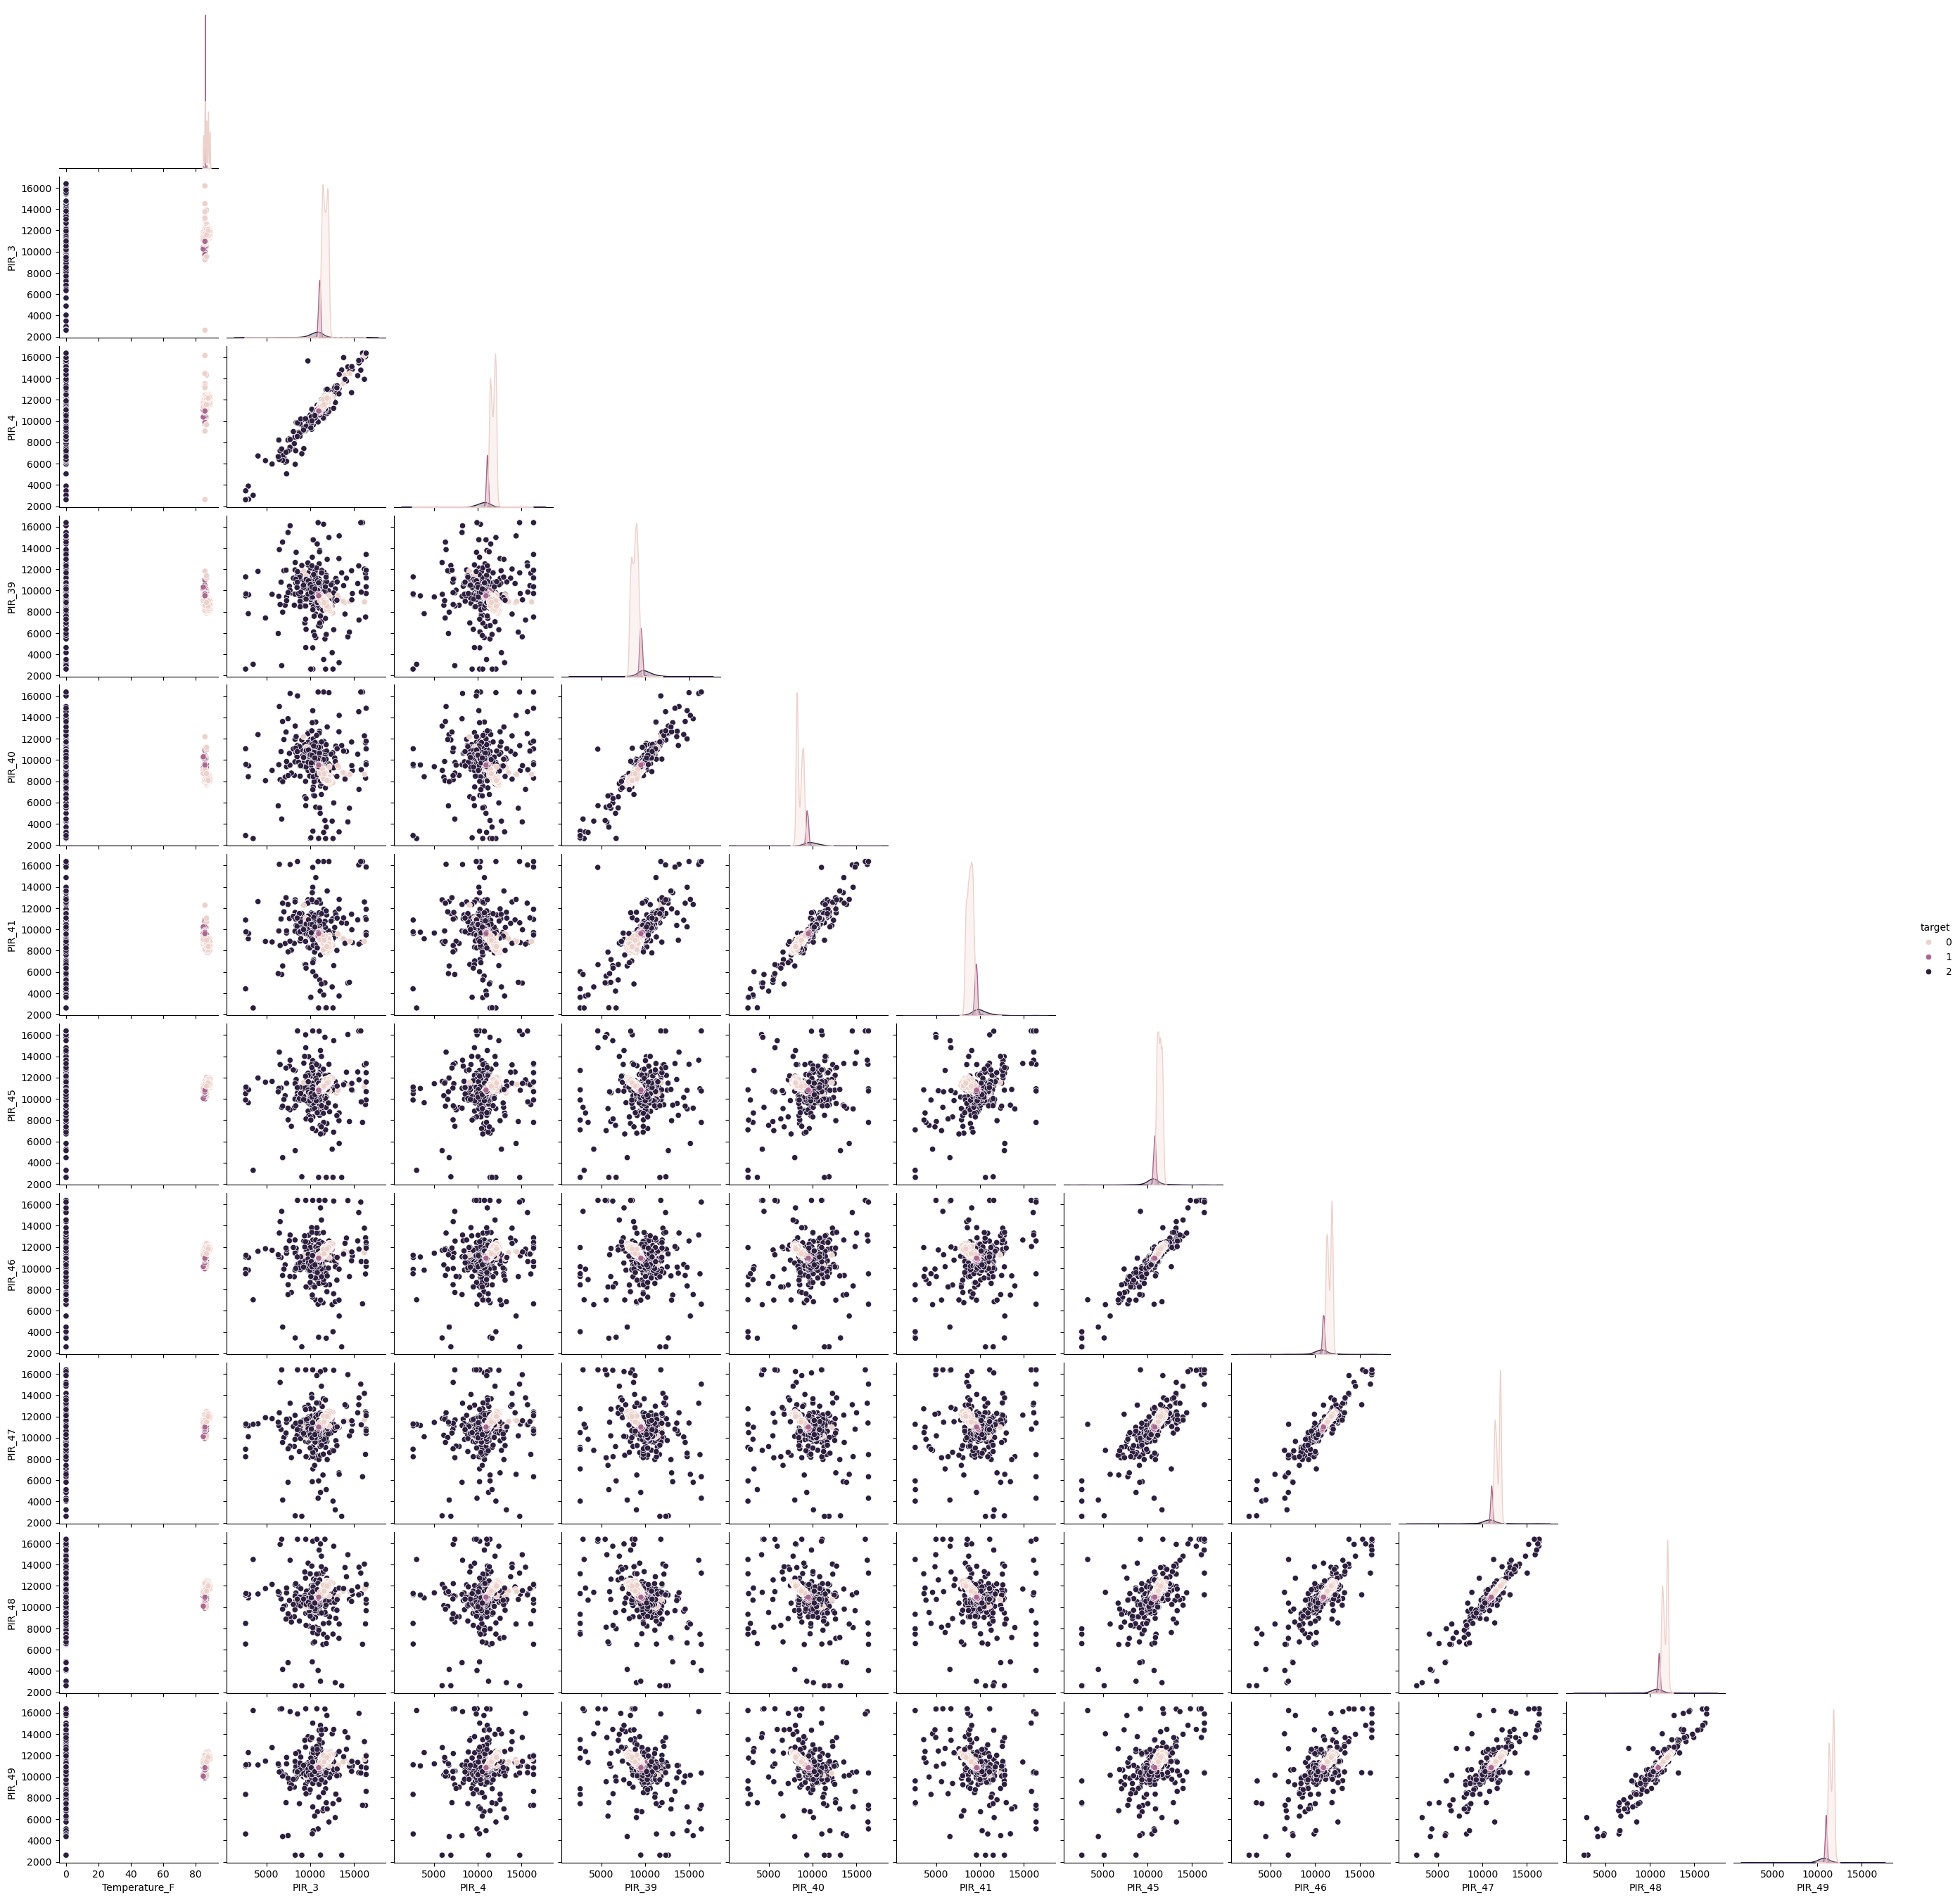

In [73]:
sns.pairplot(selected_Features, hue='target', corner=True)
plt.show()